<a href="https://colab.research.google.com/github/Vijayalakshmitce/8-2-demo/blob/master/HelmNet_Full_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

## **Business Context**

Workplace safety in hazardous environments like construction sites and industrial plants is crucial to prevent accidents and injuries. One of the most important safety measures is ensuring workers wear safety helmets, which protect against head injuries from falling objects and machinery. Non-compliance with helmet regulations increases the risk of serious injuries or fatalities, making effective monitoring essential, especially in large-scale operations where manual oversight is prone to errors and inefficiency.

To overcome these challenges, SafeGuard Corp plans to develop an automated image analysis system capable of detecting whether workers are wearing safety helmets. This system will improve safety enforcement, ensuring compliance and reducing the risk of head injuries. By automating helmet monitoring, SafeGuard aims to enhance efficiency, scalability, and accuracy, ultimately fostering a safer work environment while minimizing human error in safety oversight.

## **Objective**

As a data scientist at SafeGuard Corp, you are tasked with developing an image classification model that classifies images into one of two categories:
- **With Helmet:** Workers wearing safety helmets.
- **Without Helmet:** Workers not wearing safety helmets.

## **Data Description**

The dataset consists of **4125 images**, divided into two categories:

- **With Helmet:** 3161 images showing workers wearing helmets.
- **Without Helmet:** 964 images showing workers not wearing helmets.

**Dataset Characteristics:**
- **Variations in Conditions:** Images include diverse environments such as construction sites, factories, and industrial settings, with variations in lighting, angles, and worker postures to simulate real-world conditions.
- **Worker Activities:** Workers are depicted in different actions such as standing, using tools, or moving, ensuring robust model learning for various scenarios.

# **Installing and Importing the Necessary Libraries**

In [1]:
!pip install tensorflow[and-cuda] scikit-learn==1.6.1 opencv-python==4.12.0.88 seaborn==0.13.2 matplotlib==3.10.0 numpy==2.0.2 pandas==2.2.2 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.3/363.3 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 94.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 895.7/895.7 kB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 577.2/577.2 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.5/192.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.3/130.3 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.6/217.6 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.0/199.0 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 76.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not c

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [2]:
import os
import random
import numpy as np                                                                               # Importing numpy for Matrix Operations
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg                                                                              # Importing pandas to read CSV files
import matplotlib.pyplot as plt                                                                  # Importting matplotlib for Plotting and visualizing images
import math                                                                                      # Importing math module to perform mathematical operations
import cv2


# Tensorflow modules
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                   # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization # Defining all the layers to build our CNN Model
from tensorflow.keras.optimizers import Adam,SGD                                                 # Importing the optimizers which can be used in our model
from sklearn import preprocessing                                                                # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # Importing train_test_split function to split the data into train and test
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16                                               # Importing confusion_matrix to plot the confusion matrix

# Display images using OpenCV
from google.colab.patches import cv2_imshow

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse                                                 # Importing cv2_imshow from google.patches to display images

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)

Num GPUs Available: 1
2.19.0


In [4]:
# 1. Set Python random seed
random.seed(812)

# 2. Set NumPy random seed
np.random.seed(812)

# 3. Set TensorFlow seed (covers Keras + backend)
tf.keras.utils.set_random_seed(812)

# 4. Enable deterministic GPU ops (if using GPU)
tf.config.experimental.enable_op_determinism()

# **Data Overview**


##Loading the data

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os

print(os.listdir('/content/drive/MyDrive'))

['mca orig.gsheet', 'Untitled form [Form].gform', 'Pandivijayalakshmi Ss (1).gdoc', 'Pandivijayalakshmi Ss.gdoc', 'Sample_code_Session.txt', 'PaySlip_1891 (1).PDF', '66.jpg', 'PaySlip_1891.PDF', '1.3_RSCRCC_AAP Job Search_TC.xls', '1.1_RSCRCC_JobQueue_TC.xls', '1.2_RSCRCC_Advanced Job Search_TC.xls', '1.4_RSCRCC_Dashboard_TC.xls', '1.5_RSCRCC_Engg Comp Tasks_TC.xls', '10.2.2_Report-Finance_BT Accrual_TC.xls', '10.2.3_Report-Finance_E Bus Invoice Totals New(INT)_TC.xls', '10.2.4_Report-Finance_Outstanding Job Packs_TC.xls', '10.2.5_Report-Finance_Interims To Chase All_TC.xls', '10.2.6_Report-Finance_Pcodes Week Ending_TC.xls', 'CT-R Plan_ETON6_Build - 4.4.xls', 'CTETON_ETON6_TestReleaseNote_Build 4.9.xls', 'Deemed logic.sql', 'Enerprise Team_ Scrum notes.xls', 'Copy of CTETON_Eton6_TestLogs.xls', 'JavaBasics-notes.pdf', 'SAI BABA 108 MANTRA.txt', 'Karthik.doc', 'JMETER2.doc', 'SQLQuery1.sql', 'SQLQuery13.sql', 'SQLQuery17.sql', 'SQLQuery1e.sql', 'SQLQuery18.sql', 'SQLQuery1ee.sql', 'SQL

In [7]:
# Load the image file of the dataset
images = np.load('/content/drive/MyDrive/images.npy')

# Load the labels file of the dataset
labels = pd.read_csv('/content/drive/MyDrive/labels.csv')

Let's print the shape of the images and labels

In [8]:
print(images.shape)
print(labels.shape)

(4125, 200, 200, 3)
(4125, 1)


There are 4125 RGB  images of shape 200 x 200 X 3, each image having 3 channels.

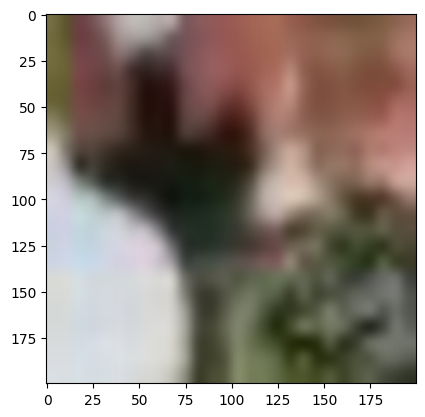

In [9]:
plt.imshow(images[5]);

# **Exploratory Data Analysis**

###Plot random images from each of the classes and print their corresponding labels.

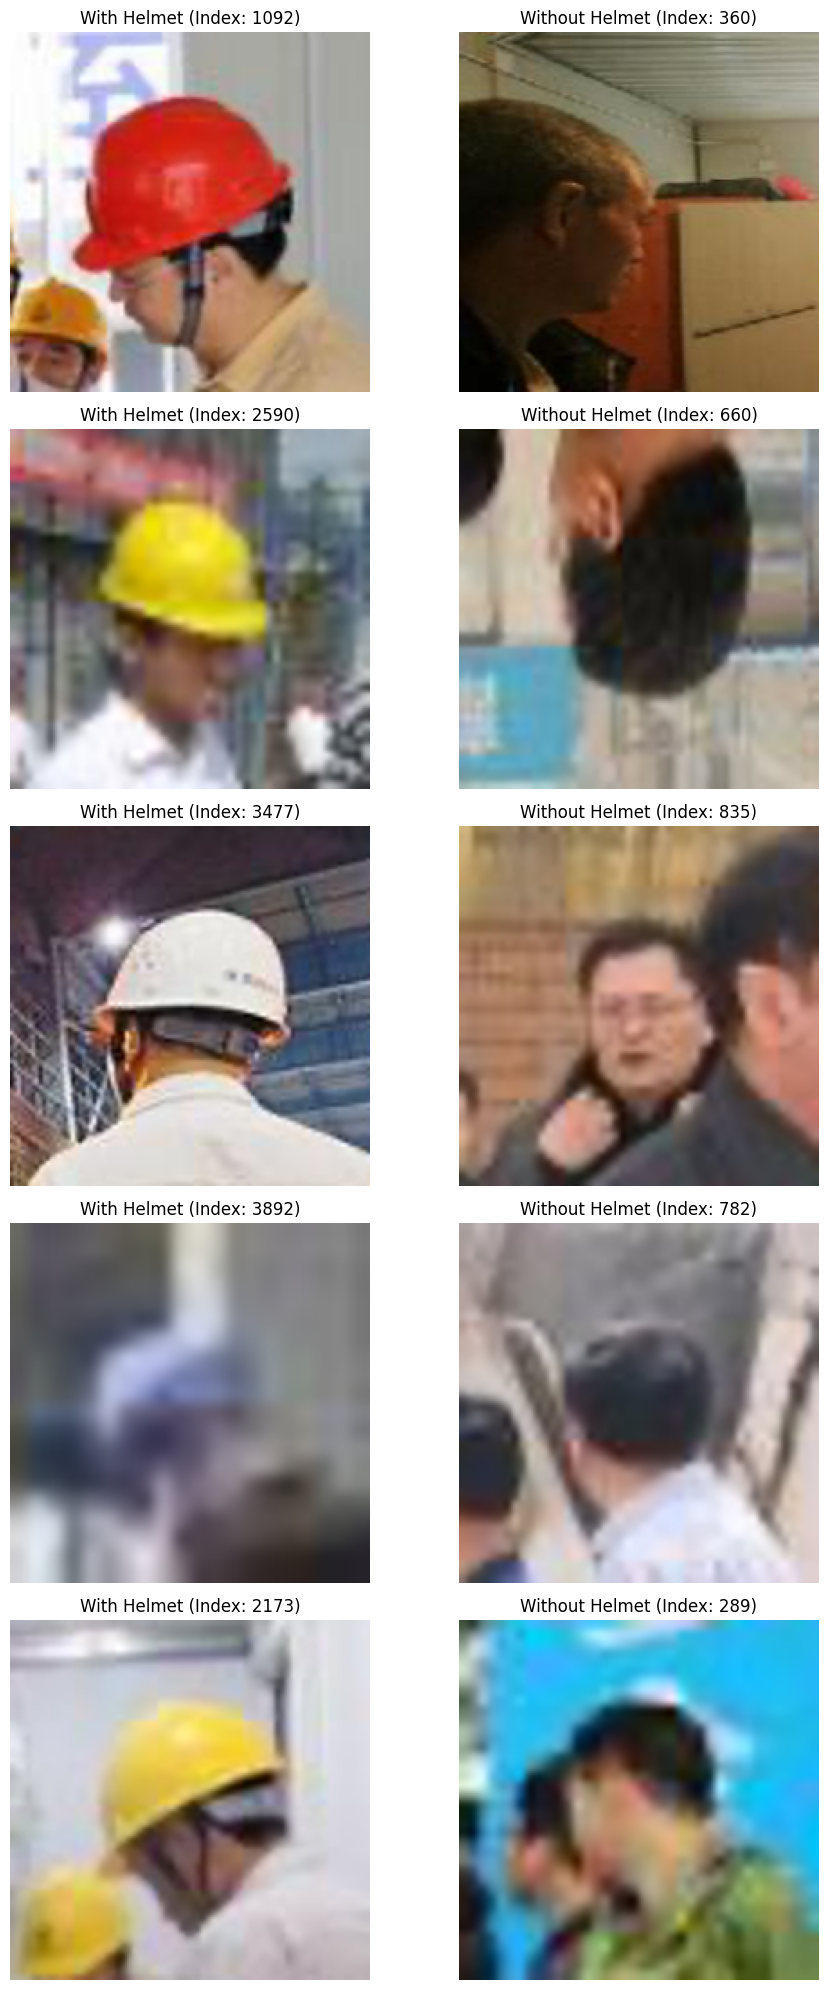

In [9]:
# Get indices for 'With Helmet' (label 1) and 'Without Helmet' (label 0)
helmet_indices = labels[labels.iloc[:, 0] == 1].index.tolist()
no_helmet_indices = labels[labels.iloc[:, 0] == 0].index.tolist()

# Select 5 random indices from each class
num_samples_to_plot = 5
random_helmet_idxs = random.sample(helmet_indices, num_samples_to_plot)
random_no_helmet_idxs = random.sample(no_helmet_indices, num_samples_to_plot)

fig, axes = plt.subplots(num_samples_to_plot, 2, figsize=(10, 4 * num_samples_to_plot))

for i in range(num_samples_to_plot):
    # Plot 'With Helmet' images
    axes[i][0].imshow(images[random_helmet_idxs[i]])
    axes[i][0].set_title(f"With Helmet (Index: {random_helmet_idxs[i]})")
    axes[i][0].axis("off")

    # Plot 'Without Helmet' images
    axes[i][1].imshow(images[random_no_helmet_idxs[i]])
    axes[i][1].set_title(f"Without Helmet (Index: {random_no_helmet_idxs[i]})")
    axes[i][1].axis("off")

plt.tight_layout()
plt.show()

## Checking for class imbalance


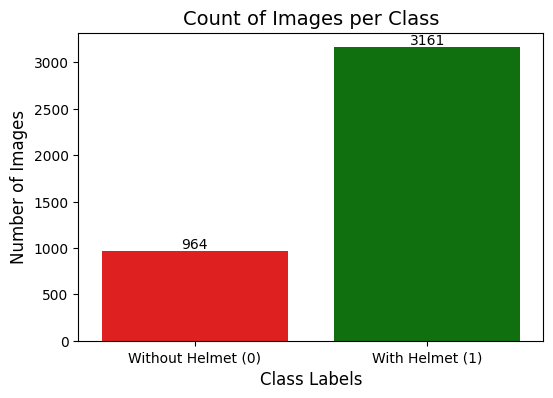

In [10]:
# Create a count plot
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=labels.iloc[:, 0], palette=['red', 'green'])

# Add exact counts on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10, )

# Add labels
plt.xlabel("Class Labels", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.title("Count of Images per Class", fontsize=14)
plt.xticks(ticks=[0, 1], labels=["Without Helmet (0)", "With Helmet (1)"])  # Rename x-axis labels

# Show plot
plt.show()

Data given is imbalanced data,without Helmet is 964 and with Helmet is 3161

# **Data Preprocessing**

### Splitting the dataset



In [11]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(np.array(images),labels , test_size=0.2, random_state=42,stratify=labels) #Complete the code to define the test_size
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp , test_size=0.5, random_state=42,stratify=y_temp) #Complete the code to define the test_size

In [13]:
print(X_train.shape,y_train.shape) #Complete the code to print the shape of the train data
print(X_val.shape,y_val.shape) #Complete the code to print the shape of the validation data
print(X_test.shape,y_test.shape) #Complete the code to print the shape of the test data

(3300, 200, 200, 3) (3300, 1)
(412, 200, 200, 3) (412, 1)
(413, 200, 200, 3) (413, 1)


### Data Normalization

In [12]:
X_train_normalized = X_train.astype('float32')/255.0 #Complete the code to normalize the training images
X_val_normalized = X_val.astype('float32')/255.0  #Complete the code to normalize the validation images
X_test_normalized = X_test.astype('float32')/255.0  #Complete the code to normalize the test images

In [13]:

print("Train label counts:", np.unique(y_train, return_counts=True))
print("Val label counts:", np.unique(y_val, return_counts=True))

Train label counts: (array([0, 1]), array([ 771, 2529]))
Val label counts: (array([0, 1]), array([ 96, 316]))


In [14]:
X_train_normalized = np.array(X_train_normalized, dtype='float32')  # shape: (num_samples, H, W, C)
y_train = np.array(y_train)                                         # shape: (num_samples,)

In [15]:
print("X_train_normalized shape:", X_train_normalized.shape)
print("y_train shape:", y_train.shape)

X_train_normalized shape: (3300, 200, 200, 3)
y_train shape: (3300, 1)


**Resolving imbalanced data**

In [16]:
y_train = y_train.ravel()  # shape: (3300,)

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Augmentation only for minority class
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# Separate minority class
X_train_0 = X_train_normalized[y_train == 0]
y_train_0 = y_train[y_train == 0]

# Separate majority class
X_train_1 = X_train_normalized[y_train == 1]
y_train_1 = y_train[y_train == 1]

# Use generator to oversample minority class
minority_gen = datagen.flow(X_train_0, y_train_0, batch_size=len(X_train_1), shuffle=True)

# Get oversampled images
X_train_0_upsampled, y_train_0_upsampled = next(minority_gen)

# Combine with majority class
X_train_balanced = np.concatenate([X_train_1/255.0, X_train_0_upsampled], axis=0)
y_train_balanced = np.concatenate([y_train_1, y_train_0_upsampled], axis=0)

# Shuffle
indices = np.arange(len(X_train_balanced))
np.random.shuffle(indices)
X_train_balanced = X_train_balanced[indices]
y_train_balanced = y_train_balanced[indices]

print("Balanced training data counts:", np.unique(y_train_balanced, return_counts=True))

Balanced training data counts: (array([0, 1]), array([ 771, 2529]))


# **Model Building**

##Model Evaluation Criterion

## Utility Functions

In [18]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

def model_performance_classification(model, predictors, target):
    """
    Function to compute metrics for a binary classification model.

    model: trained classifier
    predictors: independent variables (X)
    target: dependent variable (y), NumPy array or Pandas Series
    """

    # Convert target to 1D NumPy array
    if not isinstance(target, np.ndarray):
        target = np.array(target)
    target = target.reshape(-1)

    # Predict probabilities and convert to binary labels
    pred_prob = model.predict(predictors)
    if pred_prob.ndim > 1 and pred_prob.shape[1] == 1:
        pred = (pred_prob.reshape(-1) > 0.5).astype(int)
    else:
        pred = np.argmax(pred_prob, axis=1)

    # Compute metrics
    acc = accuracy_score(target, pred)
    recall = recall_score(target, pred)
    precision = precision_score(target, pred)
    f1 = f1_score(target, pred)

    # Create a DataFrame of metrics
    df_perf = pd.DataFrame({
        "Accuracy": [acc],
        "Recall": [recall],
        "Precision": [precision],
        "F1 Score": [f1]
    })

    return df_perf

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

def plot_confusion_matrix(model, predictors, target, ml=False):
    """
    Function to plot the confusion matrix

    model: classifier (TensorFlow/Keras model)
    predictors: independent variables (X)
    target: dependent variable (y), NumPy array or Pandas Series
    ml: boolean, True if sklearn ML model (not used here, optional)
    """

    # Ensure target is 1D NumPy array
    if not isinstance(target, np.ndarray):
        target = np.array(target)
    target = target.reshape(-1)

    # Get predictions
    pred_prob = model.predict(predictors)
    if pred_prob.ndim > 1 and pred_prob.shape[1] == 1:
        pred = (pred_prob.reshape(-1) > 0.5).astype(int)
    else:
        pred = np.argmax(pred_prob, axis=1)

    # Compute confusion matrix
    cm = tf.math.confusion_matrix(target, pred).numpy()  # convert to NumPy for seaborn

    # Plot heatmap
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

##Model 1: Convolutional Neural Network (CNN) from Scratch

In [20]:
# Initializing Model
model_1 = Sequential()

# Convolutional layers
model_1.add(Conv2D(16, (3, 3), activation='relu', padding="same", input_shape=(200, 200, 3))) #Complete the code to define the shape of the input image
model_1.add(MaxPooling2D((4, 4), padding='same'))
model_1.add(Conv2D(32, (3, 3), activation='relu', padding="same")) #Complete the code to define the number of output channels,the kernel shape and the activation function
model_1.add(MaxPooling2D((2, 2), padding='same')) #Complete the code to define the shape of the pooling kernel
model_1.add(Conv2D(64, (3, 3), activation='relu', padding="same")) #Complete the code to define the number of output channels,the kernel shape and the activation function
model_1.add(MaxPooling2D((2, 2)))
# Flatten and Dense layers
model_1.add(Flatten())
model_1.add(Dense(64, activation='relu'))
model_1.add(Dropout(0.3))
model_1.add(Dense(1, activation='sigmoid'))

In [21]:
# Compile with Adam Optimizer
opt = Adam(learning_rate=0.001) #Complete the code to define the learning rate.

In [22]:
model_1.compile(optimizer=opt, loss='binary_crossentropy', metrics=["accuracy","AUC"]) #Complete the code to define the metric of choice from Precision,f1_score,Recall

In [23]:
# Summary
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 200, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 613,537 (2.34 MB)

 Trainable params: 613,537 (2.34 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history_1 = model_1.fit(
            X_train_normalized, y_train,
            epochs=20, #Complete the code to define the number of epochs
            validation_data=(X_val_normalized,y_val),
            shuffle=True,
            batch_size=32, #Complete the code to define the batch size
            verbose=2
)

Epoch 1/20
104/104 - 9s - 85ms/step - AUC: 0.8926 - accuracy: 0.8427 - loss: 0.3418 - val_AUC: 0.9615 - val_accuracy: 0.9150 - val_loss: 0.2293
Epoch 2/20
104/104 - 2s - 23ms/step - AUC: 0.9520 - accuracy: 0.9021 - loss: 0.2355 - val_AUC: 0.9688 - val_accuracy: 0.9248 - val_loss: 0.1846
Epoch 3/20
104/104 - 2s - 22ms/step - AUC: 0.9656 - accuracy: 0.9209 - loss: 0.1993 - val_AUC: 0.9727 - val_accuracy: 0.9199 - val_loss: 0.1841
Epoch 4/20
104/104 - 2s - 22ms/step - AUC: 0.9718 - accuracy: 0.9252 - loss: 0.1784 - val_AUC: 0.9813 - val_accuracy: 0.9369 - val_loss: 0.1486
Epoch 5/20
104/104 - 2s - 22ms/step - AUC: 0.9785 - accuracy: 0.9352 - loss: 0.1535 - val_AUC: 0.9778 - val_accuracy: 0.9296 - val_loss: 0.1661
Epoch 6/20
104/104 - 3s - 24ms/step - AUC: 0.9812 - accuracy: 0.9412 - loss: 0.1468 - val_AUC: 0.9770 - val_accuracy: 0.9223 - val_loss: 0.1698
Epoch 7/20
104/104 - 2s - 22ms/step - AUC: 0.9845 - accuracy: 0.9476 - loss: 0.1322 - val_AUC: 0.9779 - val_accuracy: 0.9223 - val_loss:

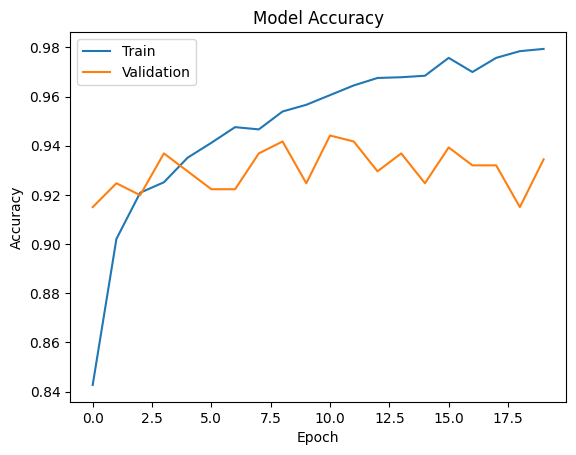

In [25]:
plt.plot(history_1.history['accuracy']) #Complete the code to plot the train metrics
plt.plot(history_1.history['val_accuracy']) #Complete the code to plot the validation data metrics
plt.title('Model Accuracy') #Complete the code to define the title for the plot
plt.ylabel('Accuracy') #Complete the code to define the label for the y-axis
plt.xlabel('Epoch') #Complete the code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [26]:
import numpy as np

# Flatten y_train to 1D
y_train = np.array(y_train).reshape(-1)  # shape: (3300,)

In [27]:
model_1_train_perf = model_performance_classification(model_1, X_train_normalized,y_train)

print("Train performance metrics")
print(model_1_train_perf)

104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step
Train performance metrics
   Accuracy   Recall  Precision  F1 Score
0  0.989394  0.99486   0.991332  0.993093


- The CNN model achieves very high training performance (Accuracy ~98.9%, F1 ~0.99), showing it has learned the training data extremely well.
- The slightly higher recall indicates a minor bias toward the positive class, but overall performance is well-balanced.

104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step


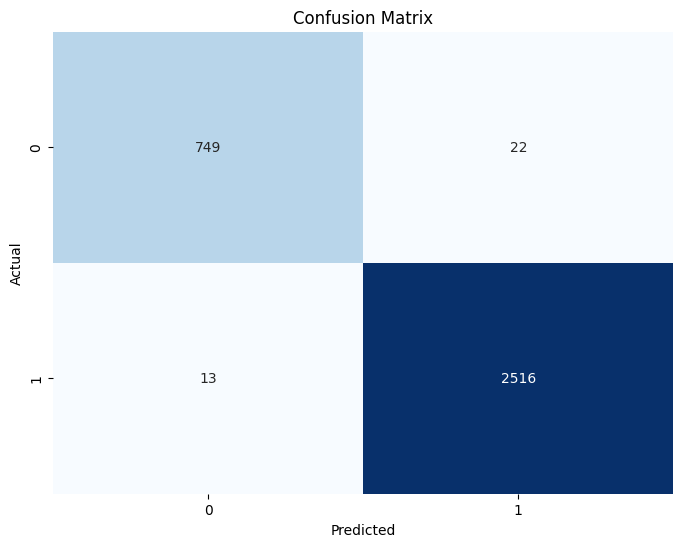

In [28]:
plot_confusion_matrix(model_1,X_train_normalized,y_train)

In [29]:
model_1_valid_perf = model_performance_classification(model_1, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_1_valid_perf)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.934466  0.968354   0.947368  0.957746


- On validation data, the CNN model maintains strong performance (Accuracy ~93.4%, F1 ~0.96), indicating good generalization from training to unseen data.
- High recall (0.97) suggests the model is slightly biased toward predicting positives, capturing most actual positives with only a few false positives.

In [30]:
y_pred = model_1.predict(X_val_normalized)
y_pred_classes = (y_pred > 0.5).astype(int)

# Count predictions
import numpy as np
unique, counts = np.unique(y_pred_classes, return_counts=True)
print(dict(zip(unique, counts)))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
{np.int64(0): np.int64(89), np.int64(1): np.int64(323)}


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


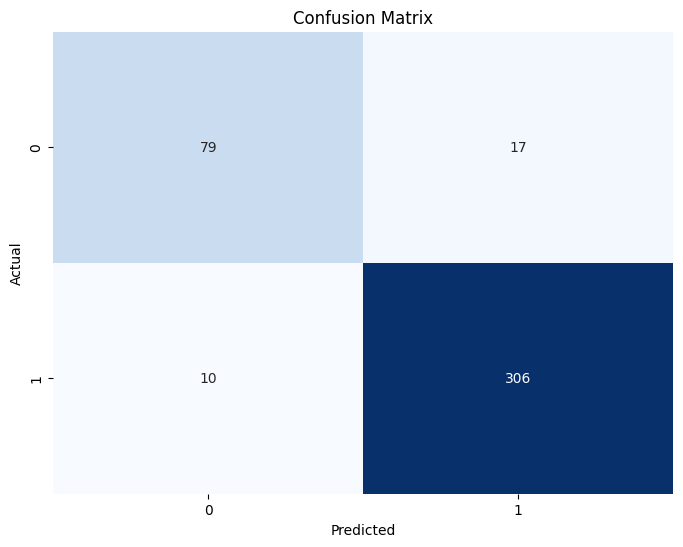

In [31]:
plot_confusion_matrix(model_1,X_val_normalized,y_val)

### Visualizing the predictions

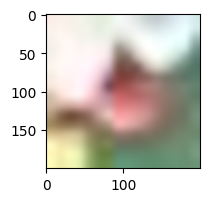

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Predicted Label: 1
True Label: label    1
Name: 3836, dtype: int64


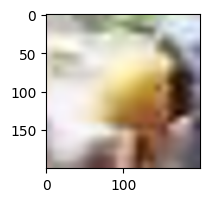

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Predicted Label: 1
True Label: label    1
Name: 3029, dtype: int64


In [32]:
# For index 12
plt.figure(figsize=(2,2))
plt.imshow(X_val[12])
plt.show()
prediction = model_1.predict(X_val_normalized[12].reshape(1,200,200,3))
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[12]
print('True Label:', true_label)

# For index 33
plt.figure(figsize=(2,2))
plt.imshow(X_val[33])
plt.show()
prediction = model_1.predict(X_val_normalized[33].reshape(1,200,200,3))
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[33]
print('True Label:', true_label)

## Model 2: Transfer Learning with VGG-16 (Base)

In [33]:
vgg_model = VGG16(weights='imagenet',include_top=False,input_shape=(200,200,3)) #Complete the code to define the shape of the image
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 200, 200, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 100, 100, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 50, 50, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 25, 25, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

### Visualizing the predictions

In [34]:
# Making all the layers of the VGG model non-trainable. i.e. freezing them
for layer in vgg_model.layers:
    layer.trainable = False

In [35]:
model_2 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_2.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_2.add(Flatten())

# Adding a dense output layer
model_2.add(Dense(1, activation='sigmoid')) #Complete the code to define the number of neurons in the output layer.

In [36]:
opt=Adam(learning_rate=0.001) #Complete the code to define the learning rate
# Compile model
model_2.compile(optimizer=opt, loss=keras.losses.BinaryCrossentropy(), metrics=["accuracy"]) #Complete the code to define the metrics

In [37]:
# Generating the summary of the model
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │        18,433 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,733,121 (56.20 MB)

 Trainable params: 18,433 (72.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [38]:
train_datagen = ImageDataGenerator()

In [39]:
# Epochs
epochs = 20 #Complete the code to define the epochs
# Batch size
batch_size = 32 #Complete the code to define the batch size

history_2 = model_2.fit(train_datagen.flow(X_train_normalized,y_train,
                                      batch_size=batch_size,
                                      seed=42,
                                      shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 16s 138ms/step - accuracy: 0.8369 - loss: 0.3705 - val_accuracy: 0.9053 - val_loss: 0.2581
Epoch 2/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9062 - loss: 0.2925 - val_accuracy: 0.8762 - val_loss: 0.2713
Epoch 3/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 14s 131ms/step - accuracy: 0.8996 - loss: 0.2370 - val_accuracy: 0.8932 - val_loss: 0.2318
Epoch 4/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8125 - loss: 0.2810 - val_accuracy: 0.9102 - val_loss: 0.2175
Epoch 5/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 14s 136ms/step - accuracy: 0.9195 - loss: 0.1999 - val_accuracy: 0.8762 - val_loss: 0.2506
Epoch 6/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9062 - loss: 0.1956 - val_accuracy: 0.8811 - val_loss: 0.2474
Epoch 7/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 14s 139ms/step - accuracy: 0.9317 - loss: 0.1716 - val_accuracy: 0.9102 - val_loss: 0.2006
Epoch 8/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 1.0000 - loss: 0.0445 - 

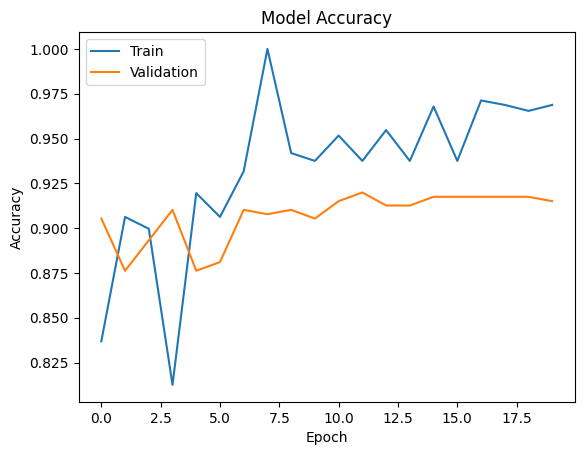

In [40]:
plt.plot(history_2.history['accuracy']) #Complete the code to plot the train metrics
plt.plot(history_2.history['val_accuracy']) #Complete the code to plot the validation data metrics
plt.title('Model Accuracy') #Complete the code to define the title for the plot
plt.ylabel('Accuracy') #Complete the code to define the label for the y-axis
plt.xlabel('Epoch') #Complete the code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [41]:
model_2_train_perf = model_performance_classification(model_2,X_train_normalized,y_train)

print("Train performance metrics")
print(model_2_train_perf)

104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 138ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.974242  0.998418   0.968918  0.983447


- The VGG-16 (Base) model shows very high training performance (Accuracy ~97.4%, F1 ~0.98), indicating it has effectively learned the training data.
- The extremely high recall (0.998) suggests a strong bias toward predicting the positive class, which may slightly reduce precision.

104/104 ━━━━━━━━━━━━━━━━━━━━ 16s 148ms/step


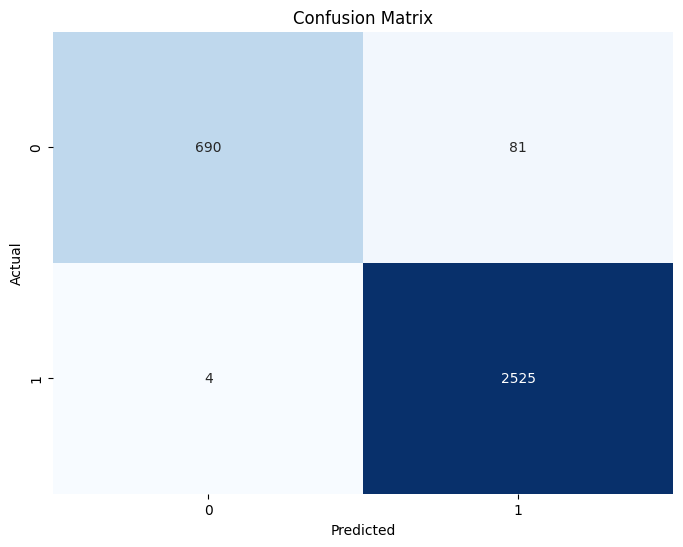

In [42]:
plot_confusion_matrix(model_2,X_train_normalized,y_train)

In [43]:
model_2_valid_perf = model_performance_classification(model_2, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_2_valid_perf)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.915049  0.987342   0.909621  0.946889


- On validation data, the VGG-16 (Base) model achieves good generalization with Accuracy ~91.5% and F1 ~0.95.
- The very high recall (0.987) indicates the model is heavily biased toward predicting positives, which increases false positives and slightly lowers precision.

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step


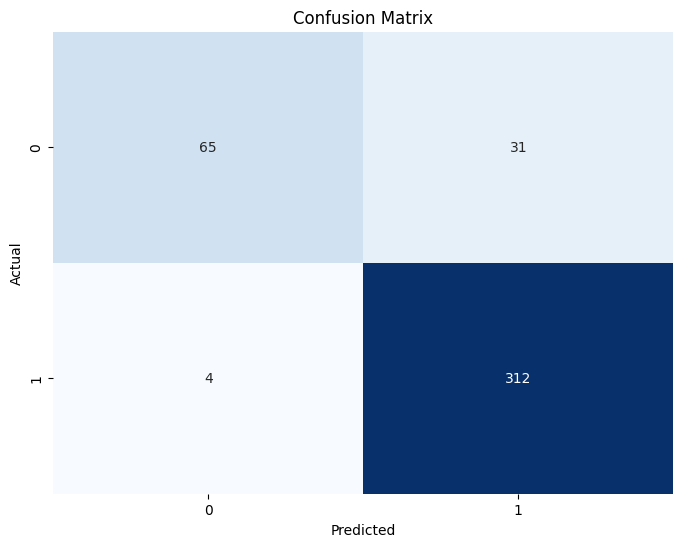

In [44]:
plot_confusion_matrix(model_2,X_val_normalized,y_val)

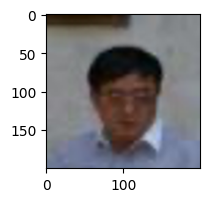

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Predicted Label: 0
True Label: label    0
Name: 214, dtype: int64


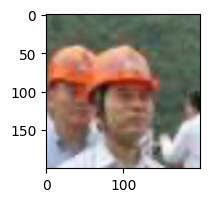

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Predicted Label: 1
True Label: label    1
Name: 2435, dtype: int64


In [45]:
plt.figure(figsize=(2,2))
plt.imshow(X_val[2]) #Complete the code to define the index
plt.show()
prediction = model_2.predict(X_val_normalized[2].reshape(1,200,200,3)) #Complete the code to define the index
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[2] #Complete the code to define the index
print('True Label:', true_label)

plt.figure(figsize=(2,2))
plt.imshow(X_val[3]) #Complete the code to define the index
plt.show()
prediction = model_2.predict(X_val_normalized[3].reshape(1,200,200,3)) #Complete the code to define the index
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[3] #Complete the code to define the index
print('True Label:', true_label)

## Model 3: Transfer Learning with VGG-16 (Base + FFNN)





In [46]:
model_3 = Sequential()

model_3.add(vgg_model)
model_3.add(Flatten())

model_3.add(Dense(256, activation='relu'))
model_3.add(Dropout(0.4))
model_3.add(Dense(32, activation='relu'))

model_3.add(Dense(1, activation='sigmoid'))

In [47]:
opt = Adam(learning_rate=0.001) #Complete the code to define the learning rate

In [48]:
# Compile model
model_3.compile(optimizer=opt,loss=keras.losses.BinaryCrossentropy(), metrics=["accuracy"]) #Complete the code to define the metrics

In [49]:
# Generating the summary of the model
model_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,441,793 (74.16 MB)

 Trainable params: 4,727,105 (18.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [50]:
history_3 = model_3.fit(train_datagen.flow(X_train_normalized,y_train,
                                       batch_size=32, #Complete the code to define the batch size
                                       seed=42,
                                       shuffle=False),
                    epochs=20, #Complete the code to define the number of epochs
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 18s 160ms/step - accuracy: 0.7742 - loss: 0.4870 - val_accuracy: 0.8786 - val_loss: 0.2972
Epoch 2/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9062 - loss: 0.3157 - val_accuracy: 0.8811 - val_loss: 0.2964
Epoch 3/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 16s 159ms/step - accuracy: 0.8693 - loss: 0.2951 - val_accuracy: 0.8835 - val_loss: 0.2731
Epoch 4/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9688 - loss: 0.2270 - val_accuracy: 0.8714 - val_loss: 0.2847
Epoch 5/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 17s 163ms/step - accuracy: 0.8898 - loss: 0.2566 - val_accuracy: 0.8641 - val_loss: 0.2565
Epoch 6/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9688 - loss: 0.1053 - val_accuracy: 0.8811 - val_loss: 0.2408
Epoch 7/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 17s 160ms/step - accuracy: 0.9021 - loss: 0.2290 - val_accuracy: 0.8908 - val_loss: 0.2477
Epoch 8/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8750 - loss: 0.2362 - 

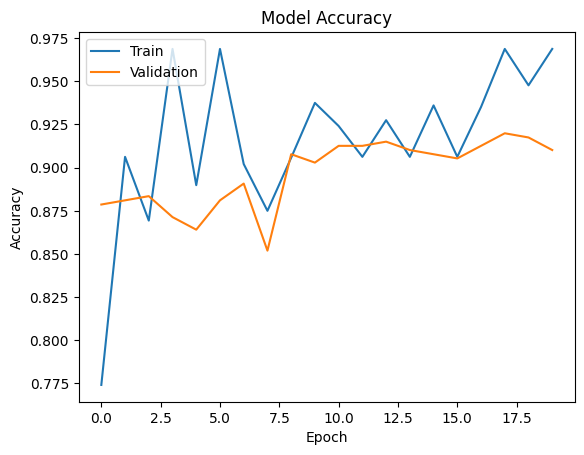

In [51]:
plt.plot(history_3.history['accuracy']) #Complete the code to plot the train metrics
plt.plot(history_3.history['val_accuracy']) #Complete the code to plot the validation data metrics
plt.title('Model Accuracy') #Complete the code to define the title for the plot
plt.ylabel('Accuracy') #Complete the code to define the label for the y-axis
plt.xlabel('Epoch') #Complete the code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [52]:
model_3_train_perf = model_performance_classification(model_3, X_train_normalized,y_train)

print("Train performance metrics")
print(model_3_train_perf)

104/104 ━━━━━━━━━━━━━━━━━━━━ 16s 139ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.965152  0.966785    0.98748  0.977023


- The VGG-16 (Base + FFNN) model shows strong training performance with Accuracy ~96.5% and F1 ~0.977, indicating effective learning of the training data.
- Precision (0.987) is slightly higher than recall (0.967), suggesting the model is more confident in positive predictions, with a few positives possibly missed.

104/104 ━━━━━━━━━━━━━━━━━━━━ 17s 153ms/step


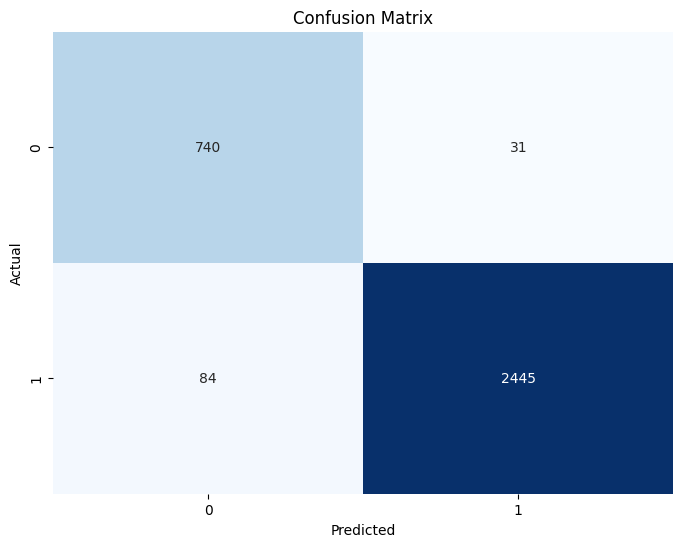

In [53]:
plot_confusion_matrix(model_3,X_train_normalized,y_train)

In [54]:
model_3_valid_perf = model_performance_classification(model_3, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_3_valid_perf)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 147ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.910194  0.927215   0.954397   0.94061


- On validation data, the VGG-16 (Base + FFNN) model achieves good generalization with Accuracy ~91% and F1 ~0.94, showing consistent performance.
- The higher precision (0.954) compared to recall (0.927) indicates the model is conservative in predicting positives, resulting in fewer false positives but slightly more false negatives.

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step


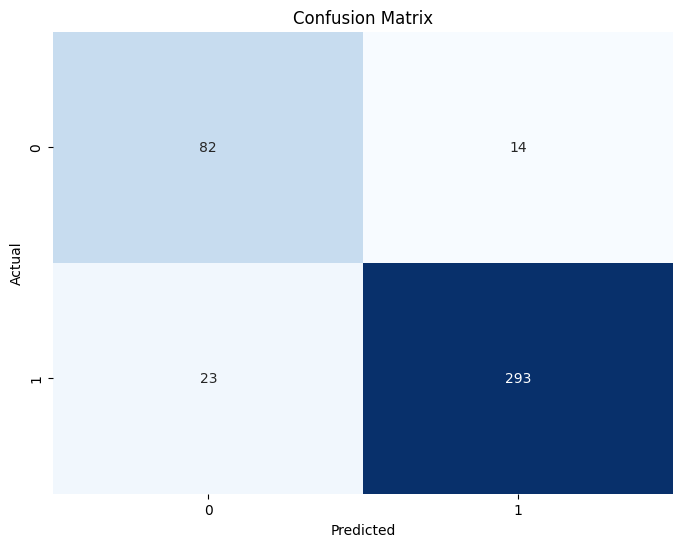

In [55]:
plot_confusion_matrix(model_3,X_val_normalized,y_val)

#### Visualizing the predictions

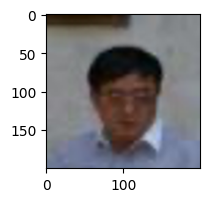

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Predicted Label: 0
True Label: label    0
Name: 214, dtype: int64


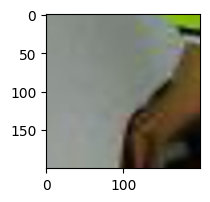

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Predicted Label: 1
True Label: label    1
Name: 1213, dtype: int64


In [56]:
plt.figure(figsize=(2,2))
plt.imshow(X_val[2]) #Complete the code to define the index
plt.show()
prediction = model_2.predict(X_val_normalized[2].reshape(1,200,200,3)) #Complete the code to define the index
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[2] #Complete the code to define the index
print('True Label:', true_label)

plt.figure(figsize=(2,2))
plt.imshow(X_val[5]) #Complete the code to define the index
plt.show()
prediction = model_2.predict(X_val_normalized[5].reshape(1,200,200,3)) #Complete the code to define the index
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[5] #Complete the code to define the index
print('True Label:', true_label)

## Model 4: Transfer Learning with VGG-16 (Base + FFNN + Data Augmentation)

- In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs.
- To overcome this problem, one approach we might consider is **Data Augmentation**.
- CNNs have the property of **translational invariance**, which means they can recognise an object even if its appearance shifts translationally in some way. - Taking this attribute into account, we can augment the images using the techniques listed below

    -  Horizontal Flip (should be set to True/False)
    -  Vertical Flip (should be set to True/False)
    -  Height Shift (should be between 0 and 1)
    -  Width Shift (should be between 0 and 1)
    -  Rotation (should be between 0 and 180)
    -  Shear (should be between 0 and 1)
    -  Zoom (should be between 0 and 1) etc.

Remember, **data augmentation should not be used in the validation/test data set**.

In [57]:
model_4 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_4.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_4.add(Flatten())

#Adding the Feed Forward neural network
model_4.add(Dense(256,activation='relu')) #Complete the code to define the number of neurons and the activation function
model_4.add(Dropout(rate=0.5)) #Complete the code to define the dropout rate
model_4.add(Dense(128,activation='relu')) #Complete the code to define the number of neurons and the activation function

# Adding a dense output layer
model_4.add(Dense(1, activation='sigmoid')) #Complete the code to define the number of neurons in the output layer and the actiavtion function

In [58]:
opt=Adam(learning_rate=0.001)
# Compile model
model_4.compile(optimizer=opt,   loss=keras.losses.BinaryCrossentropy(), metrics=["accuracy"]) #Complete the code to define the metrics

In [59]:
# Generating the summary of the model
model_4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,466,561 (74.26 MB)

 Trainable params: 4,751,873 (18.13 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [60]:
train_datagen = ImageDataGenerator(
    rotation_range=20,        # rotate images randomly ±20 degrees
    fill_mode='nearest',
    width_shift_range=0.1,    # shift width by ±10%
    height_shift_range=0.1,   # shift height by ±10%
    shear_range=0.1,          # shear transformation ±10%
    zoom_range=0.1            # zoom in/out ±10%
) #Complete the code to define the parameters for the data augmentation

In [61]:
history_4 = model_4.fit(train_datagen.flow(X_train_normalized,y_train,
                                       batch_size=32, #Complete the code to define the batch size
                                       seed=42,
                                       shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 43s 398ms/step - accuracy: 0.7549 - loss: 0.5468 - val_accuracy: 0.8155 - val_loss: 0.3588
Epoch 2/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8750 - loss: 0.2978 - val_accuracy: 0.8180 - val_loss: 0.3521
Epoch 3/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 40s 389ms/step - accuracy: 0.8268 - loss: 0.3869 - val_accuracy: 0.8738 - val_loss: 0.2789
Epoch 4/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8750 - loss: 0.2117 - val_accuracy: 0.8762 - val_loss: 0.2723
Epoch 5/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 40s 388ms/step - accuracy: 0.8204 - loss: 0.3679 - val_accuracy: 0.8981 - val_loss: 0.2613
Epoch 6/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9062 - loss: 0.2621 - val_accuracy: 0.8981 - val_loss: 0.2614
Epoch 7/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 40s 388ms/step - accuracy: 0.8427 - loss: 0.3335 - val_accuracy: 0.9029 - val_loss: 0.2995
Epoch 8/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8438 - loss: 0.3865 - 

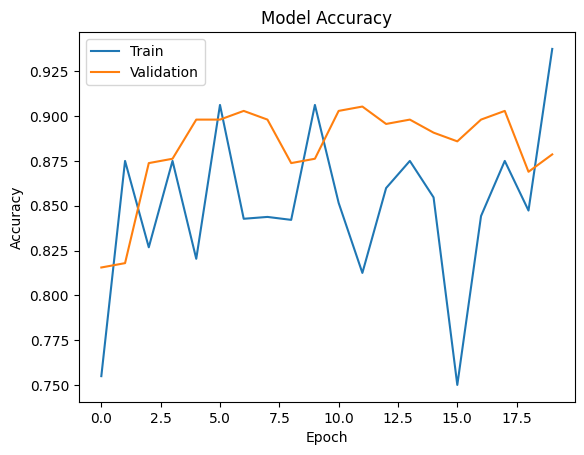

In [62]:
plt.plot(history_4.history['accuracy']) #Complete the code to plot the train metrics
plt.plot(history_4.history['val_accuracy']) #Complete the code to plot the validation data metrics
plt.title('Model Accuracy') #Complete the code to define the title for the plot
plt.ylabel('Accuracy') #Complete the code to define the label for the y-axis
plt.xlabel('Epoch') #Complete the code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [63]:
model_4_train_perf = model_performance_classification(model_4, X_train_normalized,y_train)

print("Train performance metrics")
print(model_4_train_perf)

104/104 ━━━━━━━━━━━━━━━━━━━━ 14s 123ms/step
Train performance metrics
   Accuracy   Recall  Precision  F1 Score
0  0.904545  0.98537   0.899639  0.940555


- The VGG-16 (Base + FFNN + Data Augmentation) model shows moderate training performance with Accuracy ~90.5% and F1 ~0.94, reflecting the added difficulty from augmented data.
- The very high recall (0.985) combined with lower precision (0.90) indicates the model is biased toward predicting positives, capturing most true positives but generating more false positives.

104/104 ━━━━━━━━━━━━━━━━━━━━ 14s 125ms/step


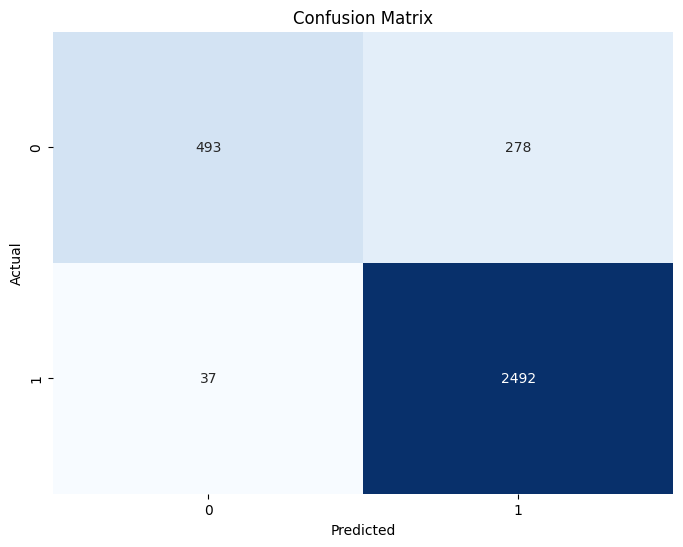

In [64]:
plot_confusion_matrix(model_4,X_train_normalized,y_train)

In [65]:
model_4_valid_perf = model_performance_classification(model_4, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_4_valid_perf)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.878641  0.990506   0.869444  0.926036


- On validation data, the VGG-16 (Base + FFNN + Data Augmentation) model shows good generalization with F1 ~0.926, though accuracy drops to ~87.9% due to harder augmented samples.
- The very high recall (0.991) and lower precision (0.869) indicate the model is strongly biased toward predicting positives, capturing nearly all true positives but producing more false positives.

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step


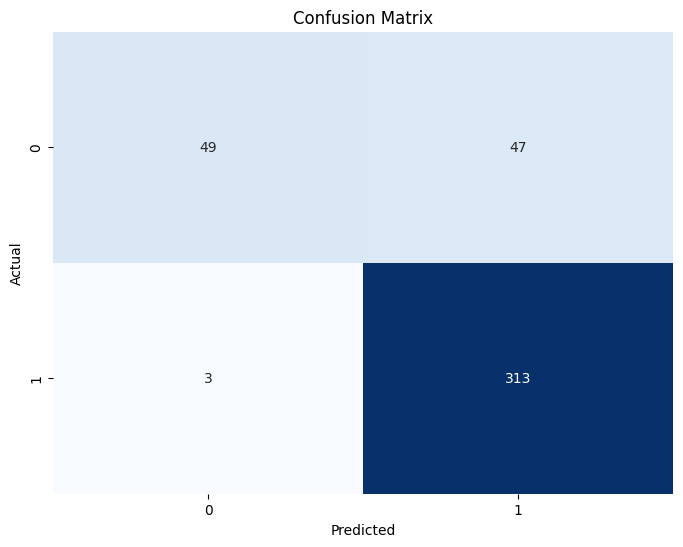

In [66]:
plot_confusion_matrix(model_4,X_val_normalized,y_val)

#### Visualizing the predictions

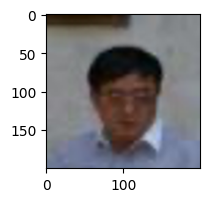

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Predicted Label: 0
True Label: label    0
Name: 214, dtype: int64


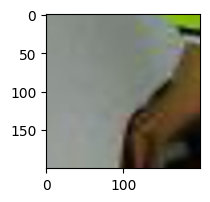

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Predicted Label: 1
True Label: label    1
Name: 1213, dtype: int64


In [67]:
plt.figure(figsize=(2,2))
plt.imshow(X_val[2]) #Complete the code to define the index
plt.show()
prediction = model_2.predict(X_val_normalized[2].reshape(1,200,200,3)) #Complete the code to define the index
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[2] #Complete the code to define the index
print('True Label:', true_label)

plt.figure(figsize=(2,2))
plt.imshow(X_val[5]) #Complete the code to define the index
plt.show()
prediction = model_2.predict(X_val_normalized[5].reshape(1,200,200,3)) #Complete the code to define the index
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
# Fix indexing issue in y_val
true_label = y_val.iloc[5] #Complete the code to define the index
print('True Label:', true_label)

# **Model Performance Comparison and Final Model Selection**

In [68]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        model_1_train_perf.T,
        model_2_train_perf.T,
        model_3_train_perf.T,
        model_4_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Simple Convolutional Neural Network (CNN)","VGG-16 (Base)","VGG-16 (Base+FFNN)","VGG-16 (Base+FFNN+Data Aug)"
]

In [69]:
models_valid_comp_df = pd.concat(
    [
        model_1_valid_perf.T,
        model_2_valid_perf.T,
        model_3_valid_perf.T,
        model_4_valid_perf.T

    ],
    axis=1,
)
models_valid_comp_df.columns = [
 "Simple Convolutional Neural Network (CNN)","VGG-16 (Base)","VGG-16 (Base+FFNN)","VGG-16 (Base+FFNN+Data Aug)"
]

In [70]:
models_train_comp_df

,Simple Convolutional Neural Network (CNN),VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.989394,0.974242,0.965152,0.904545
Recall,0.994860,0.998418,0.966785,0.985370
Precision,0.991332,0.968918,0.987480,0.899639
F1 Score,0.993093,0.983447,0.977023,0.940555


In [71]:
models_valid_comp_df

,Simple Convolutional Neural Network (CNN),VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.934466,0.915049,0.910194,0.878641
Recall,0.968354,0.987342,0.927215,0.990506
Precision,0.947368,0.909621,0.954397,0.869444
F1 Score,0.957746,0.946889,0.940610,0.926036


In [72]:
models_train_comp_df - models_valid_comp_df

,Simple Convolutional Neural Network (CNN),VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.054928,0.059194,0.054957,0.025905
Recall,0.026505,0.011077,0.039570,-0.005137
Precision,0.043963,0.059297,0.033082,0.030195
F1 Score,0.035346,0.036558,0.036413,0.014519


The train-validation difference analysis shows that the Simple CNN model exhibits minimal overfitting with a small performance gap. VGG16-based models demonstrate slightly higher gaps, indicating moderate overfitting. However, the VGG16 model with data augmentation achieves the lowest gap, and even shows negative recall difference, suggesting improved generalization due to exposure to more diverse training samples. Overall, data augmentation helps reduce overfitting, while the Simple CNN remains the most stable model.

Best accuracy model → CNN
Best generalization model → VGG16 + Aug

## Test Performance

In [73]:
model_test_perf = model_performance_classification(model_1, X_test_normalized,y_test) #Complete the code to pass the best model (Pass the variable corresponding to it. For example, model_1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [74]:
model_test_perf

,Accuracy,Recall,Precision,F1 Score
0,0.910412,0.952532,0.931889,0.942097


- The CNN model achieves strong test performance with 91% accuracy and 0.94     F1-score, indicating good balance between precision and recall.
- With high recall (0.95) compared to precision (0.93), the model is slightly biased toward detecting positives, which may lead to a few false positives but ensures most actual positives are captured.

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


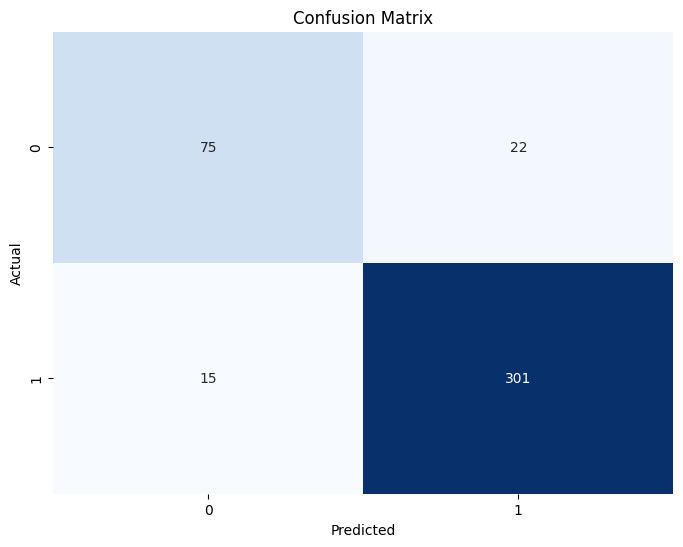

In [75]:
plot_confusion_matrix(model_1, X_test_normalized,y_test) #Complete the code to pass the best model (Pass the variable corresponding to it. For example, model_1)

# **Actionable Insights & Recommendations**

**Action**
- Adjust decision threshold
- Increase threshold (e.g., 0.5 → 0.6) to reduce false positives.
- Apply class weights during training
- Give higher weight to minority class (class 0) to reduce bias.
- Inspect misclassified samples
- Analyze false positives (22) and false negatives (15) for patterns or errors.
- Tune model hyperparameters
- Add dropout, adjust learning rate, and refine architecture slightly.
- Use proper evaluation metrics
- Focus on F1-score, precision, recall, and confusion matrix—not just accuracy.

**Recommendation**
- Reduce false positives
- Since FP = 22, prioritize improving precision without hurting recall too much.
- Maintain high recall
- Current recall (0.95) is strong—ensure it doesn’t drop significantly.
- Balance precision and recall
- Aim for an optimal trade-off rather than maximizing only one metric.
- Align model with business goal
- Decide whether false positives or false negatives are more critical.
- Avoid over-complex models
- Your current model performs well—prefer fine-tuning over adding complexity.

<font size=5 color='blue'>Power Ahead!</font>
___